<a href="https://colab.research.google.com/github/Osterne/codes_DS_course/blob/main/aula02_organizacao_qualidade_dados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Organização e Qualidade dos Dados

**Material de autoria de Vinícius Osterne, PhD (Estatístico, Mestre e Doutor)**

---

Este notebook cobre os fundamentos da qualidade de dados em projetos de ciência de dados e machine learning. Está organizado em cinco blocos principais:

1. O que é qualidade dos dados e por que importa
2. Tipos de variáveis
3. Estrutura tabular: linhas, colunas e granularidade
4. Formatos de arquivo e boas práticas
5. Inconsistências comuns nos dados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io
import os
from IPython.display import display

np.random.seed(42)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

<br>

---

## 1. O que é qualidade dos dados e por que importa

<br>

**Princípio fundamental: garbage in, garbage out.**

- Um modelo só é tão bom quanto os dados que o alimentam
- Dados de baixa qualidade produzem modelos imprecisos, independente do algoritmo utilizado
- Estima-se que engenheiros de dados gastam entre 60% e 80% do tempo em limpeza e preparação
- Detectar problemas cedo reduz o custo de correção ao longo do projeto
- Regulações como LGPD e GDPR exigem que os dados sejam precisos, completos e atualizados
- Quando um modelo falha, dados de baixa qualidade são a primeira causa a investigar antes de ajustar hiperparâmetros

<br>

**As cinco dimensões da qualidade:**

| Dimensão | Definição | Impacto no modelo |
|---|---|---|
| Completude | Ausência de valores faltantes críticos | Viés de seleção, descarte de variáveis importantes |
| Consistência | Sem contradições entre campos relacionados | Modelos aprendem padrões falsos |
| Acurácia | Valores refletem a realidade | Análises inteiras invalidadas sem aviso |
| Unicidade | Sem registros duplicados | Frequências e perfis distorcidos |
| Atualidade | Dados representam o período correto | Deriva do modelo ao longo do tempo |

<br>

In [2]:
# Exemplo pratico: dataset com problemas em cada dimensao de qualidade
dados_brutos = pd.DataFrame({
    'id_cliente':   [1, 2, 2, 3, 4, 5, 5, 6, 7, 8],
    'nome':         ['Ana', 'Bruno', 'Bruno', 'Carla', 'Diego', 'Eva', 'Eva', 'Fabio', 'Gabi', 'Helio'],
    'idade':        [28, 34, 34, -5, 45, 29, 29, 200, 38, 41],
    'cidade':       ['São Paulo', 'sao paulo', 'sao paulo', 'Rio de Janeiro', 'RJ',
                     'Curitiba', 'Curitiba', 'curitiba', 'Manaus', 'Manaus'],
    'renda_mensal': [3500, 7200, 7200, None, 9800, 4100, 4100, 6300, None, 5500],
    'data_cadastro':['2023-01-15', '2023-02-20', '2023-02-20', '2023-03-10', '15/04/2023',
                     '2023-05-05', '2023-05-05', '2023-06-18', '2023-07-22', '2023-08-30']
})

print('Dataset com problemas de qualidade:')
display(dados_brutos)
print(f'\nDimensoes: {dados_brutos.shape[0]} linhas x {dados_brutos.shape[1]} colunas')

Dataset com problemas de qualidade:


,id_cliente,nome,idade,cidade,renda_mensal,data_cadastro
0,1,Ana,28,São Paulo,3500.00,2023-01-15
1,2,Bruno,34,sao paulo,7200.00,2023-02-20
2,2,Bruno,34,sao paulo,7200.00,2023-02-20
3,3,Carla,-5,Rio de Janeiro,NaN,2023-03-10
4,4,Diego,45,RJ,9800.00,15/04/2023
5,5,Eva,29,Curitiba,4100.00,2023-05-05
6,5,Eva,29,Curitiba,4100.00,2023-05-05
7,6,Fabio,200,curitiba,6300.00,2023-06-18
8,7,Gabi,38,Manaus,NaN,2023-07-22
9,8,Helio,41,Manaus,5500.00,2023-08-30



Dimensoes: 10 linhas x 6 colunas


In [3]:
# Avaliacao rapida de qualidade
print('=== AVALIACAO DE QUALIDADE ===')

print('\n1. Tipos de dados:')
print(dados_brutos.dtypes)

print('\n2. Valores nulos por coluna:')
nulos = dados_brutos.isnull().sum()
pct_nulos = (nulos / len(dados_brutos) * 100).round(1)
resumo = pd.DataFrame({'qtd_nulos': nulos, 'pct_nulos': pct_nulos})
print(resumo[resumo['qtd_nulos'] > 0])

print('\n3. Duplicatas:')
print(f'  Linhas completamente duplicadas: {dados_brutos.duplicated().sum()}')
print(f'  IDs de clientes duplicados:      {dados_brutos.duplicated(subset=["id_cliente"]).sum()}')

print('\n4. Valores impossiveis em idade:')
print(dados_brutos[(dados_brutos['idade'] < 0) | (dados_brutos['idade'] > 120)])

=== AVALIACAO DE QUALIDADE ===

1. Tipos de dados:
id_cliente         int64
nome              object
idade              int64
cidade            object
renda_mensal     float64
data_cadastro     object
dtype: object

2. Valores nulos por coluna:
              qtd_nulos  pct_nulos
renda_mensal          2      20.00

3. Duplicatas:
  Linhas completamente duplicadas: 2
  IDs de clientes duplicados:      2

4. Valores impossiveis em idade:
   id_cliente   nome  idade          cidade  renda_mensal data_cadastro
3           3  Carla     -5  Rio de Janeiro           NaN    2023-03-10
7           6  Fabio    200        curitiba       6300.00    2023-06-18


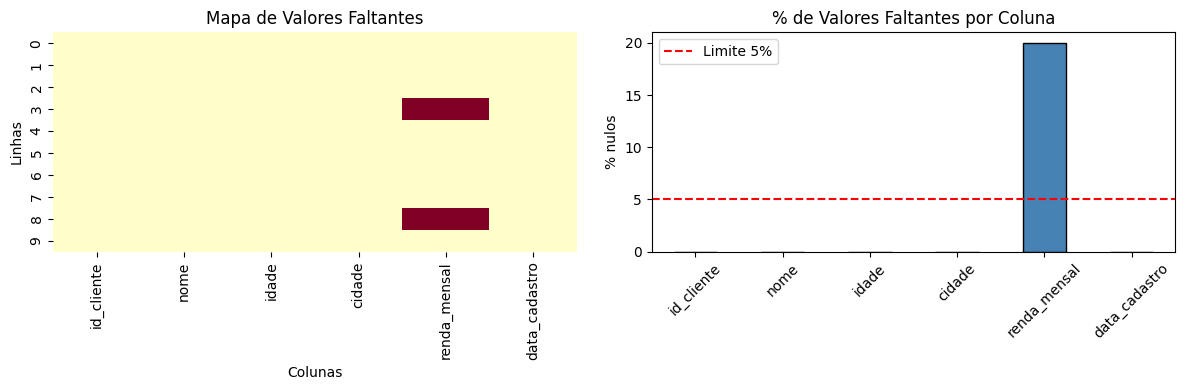

In [4]:
# Visualizacao: mapa de faltantes e percentual por coluna
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(dados_brutos.isnull(), cbar=False, cmap='YlOrRd', ax=axes[0])
axes[0].set_title('Mapa de Valores Faltantes')
axes[0].set_xlabel('Colunas')
axes[0].set_ylabel('Linhas')

pct = (dados_brutos.isnull().sum() / len(dados_brutos) * 100)
pct.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('% de Valores Faltantes por Coluna')
axes[1].set_ylabel('% nulos')
axes[1].tick_params(axis='x', rotation=45)
axes[1].axhline(y=5, color='red', linestyle='--', label='Limite 5%')
axes[1].legend()

plt.tight_layout()
plt.show()

<br>

---

## 2. Tipos de variáveis

<br>

O tipo da variável determina quais técnicas de limpeza, transformação e modelagem são adequadas.

<br>

**Quantitativas:**
- **Contínuas** assumem qualquer valor real em um intervalo. Exemplos: altura, temperatura, renda
- **Discretas** assumem apenas valores inteiros e contáveis. Exemplos: número de filhos, quantidade de compras

<br>

**Qualitativas:**
- **Nominais** não possuem ordem entre as categorias. Exemplos: cor dos olhos, cidade, estado civil
- **Ordinais** possuem ordem definida entre as categorias. Exemplos: grau de satisfação, nível educacional
- **Binárias** são um caso especial com apenas dois valores possíveis. Exemplos: sim/não, 0/1, verdadeiro/falso

<br>

**Erro comum:** aplicar estatísticas de um tipo sobre outro produz resultados incorretos sem nenhum aviso de erro.

<br>

In [5]:
# Criando um dataset com os diferentes tipos de variaveis
n = 200

df_tipos = pd.DataFrame({
    'altura_m':        np.random.normal(1.70, 0.10, n).round(2),         # continua
    'renda_mensal':    np.random.lognormal(8.5, 0.6, n).round(2),        # continua assimetrica
    'num_filhos':      np.random.poisson(1.2, n),                        # discreta
    'qtd_compras_mes': np.random.poisson(3.5, n),                        # discreta
    'cidade':          np.random.choice(['São Paulo', 'Rio de Janeiro', 'Curitiba', 'Manaus', 'Recife'], n),
    'estado_civil':    np.random.choice(['Solteiro', 'Casado', 'Divorciado', 'Viuvo'], n, p=[0.4, 0.4, 0.15, 0.05]),
    'escolaridade':    np.random.choice(['Fundamental', 'Medio', 'Superior', 'Pos-graduacao'], n, p=[0.15, 0.35, 0.35, 0.15]),
    'satisfacao':      np.random.choice([1, 2, 3, 4, 5], n, p=[0.05, 0.10, 0.25, 0.40, 0.20]),
    'tem_carro':       np.random.choice([0, 1], n, p=[0.35, 0.65]),
    'inadimplente':    np.random.choice([False, True], n, p=[0.85, 0.15]),
})

print('Tipos de dados identificados pelo pandas:')
print(df_tipos.dtypes)
print('\nObs: o pandas nao distingue nominal de ordinal automaticamente.')

Tipos de dados identificados pelo pandas:
altura_m           float64
renda_mensal       float64
num_filhos           int64
qtd_compras_mes      int64
cidade              object
estado_civil        object
escolaridade        object
satisfacao           int64
tem_carro            int64
inadimplente          bool
dtype: object

Obs: o pandas nao distingue nominal de ordinal automaticamente.


In [6]:
# Estatisticas adequadas por tipo
print('=== CONTINUAS: media, desvio, quartis ===')
print(df_tipos[['altura_m', 'renda_mensal']].describe().round(2))

print('\n=== DISCRETAS: frequencia de valores ===')
print(df_tipos['num_filhos'].value_counts().sort_index())

print('\n=== NOMINAL: frequencia sem ordem ===')
print(df_tipos['cidade'].value_counts())

print('\n=== ORDINAL: frequencia com ordem correta ===')
ordem = ['Fundamental', 'Medio', 'Superior', 'Pos-graduacao']
print(df_tipos['escolaridade'].value_counts().reindex(ordem))

print('\n=== BINARIA: proporcao ===')
print(f'inadimplente: {df_tipos["inadimplente"].mean()*100:.1f}% positivos')

=== CONTINUAS: media, desvio, quartis ===
       altura_m  renda_mensal
count    200.00        200.00
mean       1.70       6225.60
std        0.09       4746.34
min        1.44        702.92
25%        1.63       3416.98
50%        1.70       5152.85
75%        1.75       7423.01
max        1.97      49594.68

=== DISCRETAS: frequencia de valores ===
num_filhos
0    72
1    68
2    42
3    15
4     2
5     1
Name: count, dtype: int64

=== NOMINAL: frequencia sem ordem ===
cidade
Recife            44
Manaus            43
Rio de Janeiro    40
Curitiba          38
São Paulo         35
Name: count, dtype: int64

=== ORDINAL: frequencia com ordem correta ===
escolaridade
Fundamental      38
Medio            60
Superior         71
Pos-graduacao    31
Name: count, dtype: int64

=== BINARIA: proporcao ===
inadimplente: 17.5% positivos


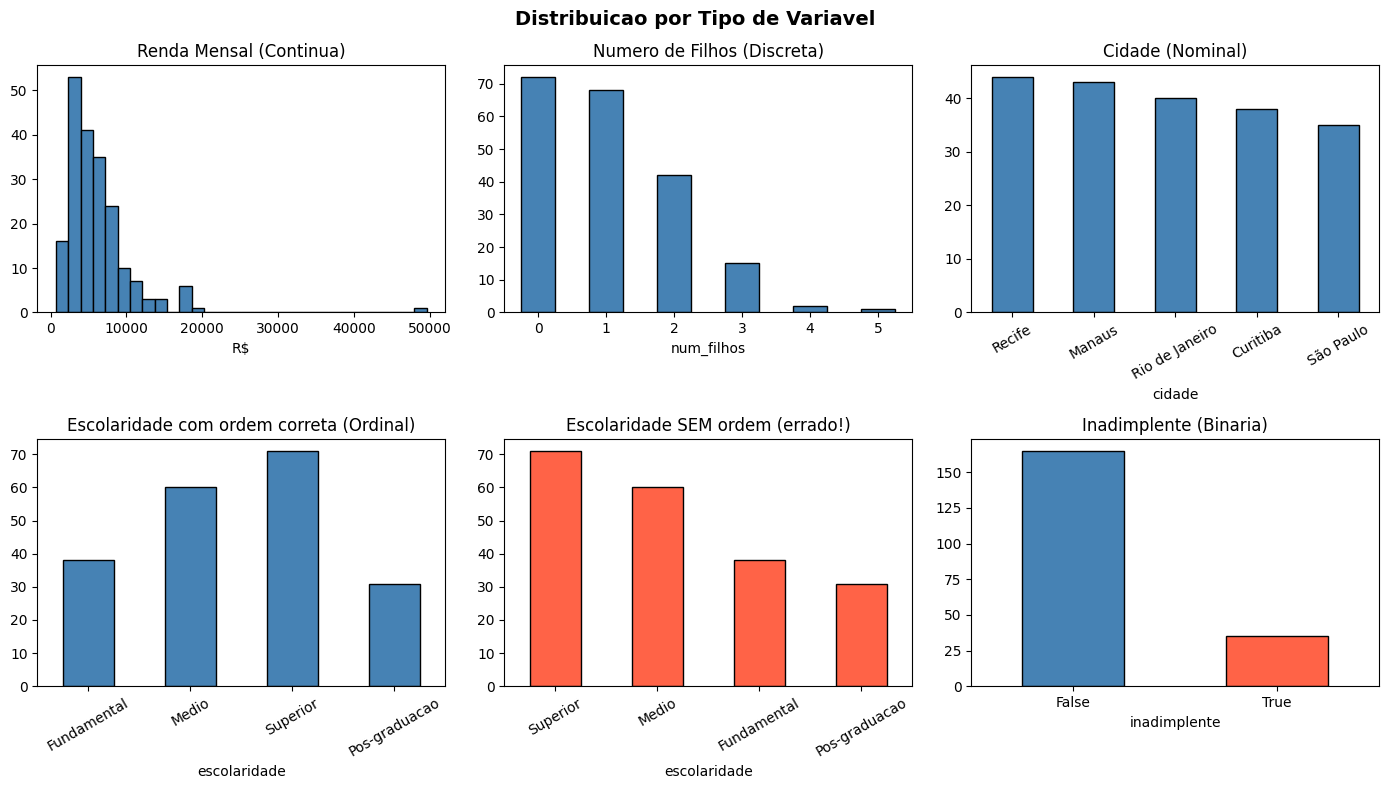

In [7]:
# Visualizacao por tipo de variavel
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
ordem = ['Fundamental', 'Medio', 'Superior', 'Pos-graduacao']

axes[0, 0].hist(df_tipos['renda_mensal'], bins=30, color='steelblue', edgecolor='black')
axes[0, 0].set_title('Renda Mensal (Continua)')
axes[0, 0].set_xlabel('R$')

df_tipos['num_filhos'].value_counts().sort_index().plot(kind='bar', ax=axes[0, 1], color='steelblue', edgecolor='black')
axes[0, 1].set_title('Numero de Filhos (Discreta)')
axes[0, 1].tick_params(axis='x', rotation=0)

df_tipos['cidade'].value_counts().plot(kind='bar', ax=axes[0, 2], color='steelblue', edgecolor='black')
axes[0, 2].set_title('Cidade (Nominal)')
axes[0, 2].tick_params(axis='x', rotation=30)

df_tipos['escolaridade'].value_counts().reindex(ordem).plot(kind='bar', ax=axes[1, 0], color='steelblue', edgecolor='black')
axes[1, 0].set_title('Escolaridade com ordem correta (Ordinal)')
axes[1, 0].tick_params(axis='x', rotation=30)

df_tipos['escolaridade'].value_counts().plot(kind='bar', ax=axes[1, 1], color='tomato', edgecolor='black')
axes[1, 1].set_title('Escolaridade SEM ordem (errado!)')
axes[1, 1].tick_params(axis='x', rotation=30)

df_tipos['inadimplente'].value_counts().plot(kind='bar', ax=axes[1, 2], color=['steelblue', 'tomato'], edgecolor='black')
axes[1, 2].set_title('Inadimplente (Binaria)')
axes[1, 2].tick_params(axis='x', rotation=0)

plt.suptitle('Distribuicao por Tipo de Variavel', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
# Codificacao correta por tipo
df_encoded = df_tipos.copy()

# Nominal: One-Hot Encoding
df_encoded = pd.get_dummies(df_encoded, columns=['cidade', 'estado_civil'], drop_first=True, dtype=int)

# Ordinal: Ordinal Encoding com mapa explicito
mapa_escolaridade = {'Fundamental': 0, 'Medio': 1, 'Superior': 2, 'Pos-graduacao': 3}
df_encoded['escolaridade_cod'] = df_tipos['escolaridade'].map(mapa_escolaridade)
df_encoded.drop(columns=['escolaridade'], inplace=True)

# Binaria: booleano para int
df_encoded['inadimplente'] = df_encoded['inadimplente'].astype(int)

print('Colunas apos codificacao correta:')
print(df_encoded.dtypes)
print(f'\nShape final: {df_encoded.shape}')

Colunas apos codificacao correta:
altura_m                   float64
renda_mensal               float64
num_filhos                   int64
qtd_compras_mes              int64
satisfacao                   int64
tem_carro                    int64
inadimplente                 int64
cidade_Manaus                int64
cidade_Recife                int64
cidade_Rio de Janeiro        int64
cidade_São Paulo             int64
estado_civil_Divorciado      int64
estado_civil_Solteiro        int64
estado_civil_Viuvo           int64
escolaridade_cod             int64
dtype: object

Shape final: (200, 15)


<br>

---

## 3. Estrutura tabular: linhas, colunas e granularidade

<br>

**A primeira pergunta antes de qualquer análise:** o que cada linha deste dataset representa?

<br>

**Granularidade** é o nível de detalhe de cada registro:
- Uma linha por **transação** é ideal para detecção de fraude e análise de eventos individuais
- Uma linha por **cliente** é ideal para segmentação e modelos de churn
- Uma linha por **dia ou período** é adequada para séries temporais
- Uma linha por **produto** é usada para sistemas de recomendação e análise de portfólio

<br>

**Granularidade incorreta é uma das principais causas de data leakage.**

<br>

**Princípios de Tidy Data (Wickham, 2014):**
- Cada variável forma uma coluna
- Cada observação forma uma linha
- Cada tipo de unidade observacional forma uma tabela separada, relacionada por chaves

<br>

In [9]:
# Mesmo dado em granularidades diferentes
transacoes = pd.DataFrame({
    'id_transacao': [1001, 1002, 1003, 1004, 1005, 1006],
    'id_cliente':   [1, 1, 2, 3, 3, 3],
    'data':         ['2024-01-05', '2024-01-18', '2024-01-07', '2024-01-02', '2024-01-15', '2024-01-28'],
    'valor':        [250.0, 80.0, 430.0, 120.0, 95.0, 310.0],
    'categoria':    ['Eletronicos', 'Livros', 'Roupas', 'Livros', 'Alimentos', 'Eletronicos']
})

print('Granularidade: uma linha por transacao')
display(transacoes)

por_cliente = transacoes.groupby('id_cliente').agg(
    total_gasto     = ('valor', 'sum'),
    num_transacoes  = ('id_transacao', 'count'),
    ticket_medio    = ('valor', 'mean'),
    primeira_compra = ('data', 'min'),
    ultima_compra   = ('data', 'max')
).reset_index()

print('\nGranularidade: uma linha por cliente (agregado)')
display(por_cliente)

Granularidade: uma linha por transacao


,id_transacao,id_cliente,data,valor,categoria
0,1001,1,2024-01-05,250.00,Eletronicos
1,1002,1,2024-01-18,80.00,Livros
2,1003,2,2024-01-07,430.00,Roupas
3,1004,3,2024-01-02,120.00,Livros
4,1005,3,2024-01-15,95.00,Alimentos
5,1006,3,2024-01-28,310.00,Eletronicos



Granularidade: uma linha por cliente (agregado)


,id_cliente,total_gasto,num_transacoes,ticket_medio,primeira_compra,ultima_compra
0,1,330.00,2,165.00,2024-01-05,2024-01-18
1,2,430.00,1,430.00,2024-01-07,2024-01-07
2,3,525.00,3,175.00,2024-01-02,2024-01-28


In [10]:
# Demonstracao de data leakage por granularidade errada
print('=== EXEMPLO DE DATA LEAKAGE POR GRANULARIDADE ===')
print()
print('Cenario: prever se o cliente vai comprar na segunda quinzena usando dados do mes inteiro.')
print()
print('ERRADO: usar total_gasto do mes inteiro como feature para prever compra da segunda quinzena')
print('  O total ja inclui as compras que voce quer prever. Leakage garantido.')
print()
print('CORRETO: definir corte temporal e separar features de target cronologicamente')
print()

corte = '2024-01-14'

features = transacoes[transacoes['data'] <= corte].groupby('id_cliente').agg(
    gasto_antes_corte   = ('valor', 'sum'),
    compras_antes_corte = ('id_transacao', 'count')
).reset_index()

target = transacoes[transacoes['data'] > corte].groupby('id_cliente').agg(
    comprou_depois = ('id_transacao', 'count')
).reset_index()
target['comprou_depois'] = (target['comprou_depois'] > 0).astype(int)

dataset_correto = features.merge(target, on='id_cliente', how='left').fillna(0)
print('Dataset com corte correto (features antes, target depois do corte):')
display(dataset_correto)

=== EXEMPLO DE DATA LEAKAGE POR GRANULARIDADE ===

Cenario: prever se o cliente vai comprar na segunda quinzena usando dados do mes inteiro.

ERRADO: usar total_gasto do mes inteiro como feature para prever compra da segunda quinzena
  O total ja inclui as compras que voce quer prever. Leakage garantido.

CORRETO: definir corte temporal e separar features de target cronologicamente

Dataset com corte correto (features antes, target depois do corte):


,id_cliente,gasto_antes_corte,compras_antes_corte,comprou_depois
0,1,250.00,1,1.00
1,2,430.00,1,0.00
2,3,120.00,1,1.00


In [11]:
# Tidy Data vs Wide Data
wide = pd.DataFrame({
    'id_cliente': [1, 2, 3],
    'jan': [250, 430, 525],
    'fev': [80,  None, 180],
    'mar': [320, 615, None]
})
print('Formato WIDE (nao tidy):')
display(wide)

tidy = wide.melt(id_vars='id_cliente', var_name='mes', value_name='valor_gasto')
tidy = tidy.dropna().sort_values(['id_cliente', 'mes']).reset_index(drop=True)
print('\nFormato TIDY:')
display(tidy)
print('\nNo formato tidy fica facil filtrar, agrupar e alimentar modelos.')

Formato WIDE (nao tidy):


,id_cliente,jan,fev,mar
0,1,250,80.00,320.00
1,2,430,NaN,615.00
2,3,525,180.00,NaN



Formato TIDY:


,id_cliente,mes,valor_gasto
0,1,fev,80.00
1,1,jan,250.00
2,1,mar,320.00
3,2,jan,430.00
4,2,mar,615.00
5,3,fev,180.00
6,3,jan,525.00



No formato tidy fica facil filtrar, agrupar e alimentar modelos.


In [12]:
# Integridade referencial
clientes = pd.DataFrame({'id_cliente': [1, 2, 3, 4], 'nome': ['Ana', 'Bruno', 'Carla', 'Diego']})
pedidos  = pd.DataFrame({'id_pedido': [101, 102, 103, 104], 'id_cliente': [1, 2, 5, 3], 'valor': [100, 200, 150, 300]})

ids_invalidos = set(pedidos['id_cliente']) - set(clientes['id_cliente'])
print(f'IDs em pedidos que NAO existem em clientes: {ids_invalidos}')
print('Esses pedidos serao perdidos silenciosamente em um join inner.')

join_inner = pedidos.merge(clientes, on='id_cliente', how='inner')
join_left  = pedidos.merge(clientes, on='id_cliente', how='left')
print(f'\nPedidos originais:  {len(pedidos)}')
print(f'Apos inner join:    {len(join_inner)} (perdeu 1 pedido)')
print(f'Apos left join:     {len(join_left)}  (manteve, nome ficou como NaN)')

IDs em pedidos que NAO existem em clientes: {5}
Esses pedidos serao perdidos silenciosamente em um join inner.

Pedidos originais:  4
Apos inner join:    3 (perdeu 1 pedido)
Apos left join:     4  (manteve, nome ficou como NaN)


<br>

---

## 4. Formatos de arquivo e boas práticas

<br>

**Formatos mais utilizados:**
- **CSV** é simples e universal, mas sem tipagem nativa e sensível a problemas de separador e encoding
- **JSON** é hierárquico e flexível, ideal para APIs e objetos aninhados, ineficiente para grandes volumes tabulares
- **Parquet** é colunar, com compressão nativa e preservação de tipos, ideal para big data e pipelines com Spark
- **Excel (.xlsx)** é comum em ambientes corporativos, mas propenso a erros silenciosos de formatação

<br>

**Quando usar cada formato:**
- Prototipação rápida e intercâmbio entre sistemas heterogêneos: CSV
- Ingestão de dados de APIs REST e logs de aplicações: JSON
- Pipelines de ETL e datasets acima de 100 MB: Parquet
- Recebimento de dados de stakeholders não técnicos: Excel

<br>

**Armadilhas regionais no Brasil:**
- CSVs frequentemente usam ponto e vírgula como separador
- Decimais com vírgula, como `1.234,56`, precisam ser convertidos antes da leitura
- Datas no formato DD/MM/AAAA são ambíguas em parsers internacionais
- Encoding Latin-1 ainda é comum em sistemas legados e gera erros ao misturar com UTF-8

<br>

In [13]:
# Comparando CSV vs Parquet
df_vendas = pd.DataFrame({
    'id':      range(1, 6),
    'produto': ['Notebook', 'Mouse', 'Teclado', 'Monitor', 'Headset'],
    'preco':   [3599.90, 89.90, 199.90, 1299.90, 349.90],
    'data':    pd.to_datetime(['2024-01-10', '2024-01-11', '2024-01-12', '2024-01-13', '2024-01-14']),
    'ativo':   [True, True, False, True, True]
})

df_vendas.to_csv('/tmp/vendas.csv', index=False, encoding='utf-8')
df_vendas.to_parquet('/tmp/vendas.parquet', index=False)

tam_csv     = os.path.getsize('/tmp/vendas.csv')
tam_parquet = os.path.getsize('/tmp/vendas.parquet')
print(f'Tamanho CSV:     {tam_csv} bytes')
print(f'Tamanho Parquet: {tam_parquet} bytes')
print(f'Reducao: {(1 - tam_parquet/tam_csv)*100:.1f}% menor com Parquet')
print('A diferenca se amplifica significativamente em datasets maiores.')

Tamanho CSV:     189 bytes
Tamanho Parquet: 3262 bytes
Reducao: -1625.9% menor com Parquet
A diferenca se amplifica significativamente em datasets maiores.


In [14]:
# Preservacao de tipos: CSV vs Parquet
df_csv     = pd.read_csv('/tmp/vendas.csv')
df_parquet = pd.read_parquet('/tmp/vendas.parquet')

print('Tipos apos leitura do CSV:')
print(df_csv.dtypes)

print('\nTipos apos leitura do Parquet:')
print(df_parquet.dtypes)

print('\nObservacoes:')
print('  CSV le datas como string (object). Parquet preserva como datetime64.')
print('  CSV le booleanos como int64.       Parquet preserva como bool.')
print('  Ao usar CSV, sempre converter tipos manualmente apos a leitura.')

Tipos apos leitura do CSV:
id           int64
produto     object
preco      float64
data        object
ativo         bool
dtype: object

Tipos apos leitura do Parquet:
id                  int64
produto            object
preco             float64
data       datetime64[ns]
ativo                bool
dtype: object

Observacoes:
  CSV le datas como string (object). Parquet preserva como datetime64.
  CSV le booleanos como int64.       Parquet preserva como bool.
  Ao usar CSV, sempre converter tipos manualmente apos a leitura.


In [15]:
# Armadilhas com CSV brasileiro
csv_br = """nome;preco;data_venda
Notebook;3.599,90;15/01/2024
Mouse;89,90;20/01/2024
Monitor;1.299,90;25/01/2024"""

print('=== LEITURA ERRADA (sem tratamento) ===')
df_errado = pd.read_csv(io.StringIO(csv_br))
display(df_errado)
print('Todo o conteudo foi lido em uma unica coluna. O separador nao foi especificado.')

print('\n=== LEITURA CORRETA ===')
df_correto = pd.read_csv(io.StringIO(csv_br), sep=';', decimal=',', thousands='.')
df_correto['data_venda'] = pd.to_datetime(df_correto['data_venda'], format='%d/%m/%Y')
display(df_correto)
print('Tipos:', df_correto.dtypes.to_dict())

=== LEITURA ERRADA (sem tratamento) ===


,nome;preco;data_venda
Notebook;3.599,90;15/01/2024
Mouse;89,90;20/01/2024
Monitor;1.299,90;25/01/2024


Todo o conteudo foi lido em uma unica coluna. O separador nao foi especificado.

=== LEITURA CORRETA ===


,nome,preco,data_venda
0,Notebook,3599.90,2024-01-15
1,Mouse,89.90,2024-01-20
2,Monitor,1299.90,2024-01-25


Tipos: {'nome': dtype('O'), 'preco': dtype('float64'), 'data_venda': dtype('<M8[ns]')}


<br>

---

## 5. Inconsistências comuns nos dados

<br>

**Tipos mais frequentes:**
- **Duplicatas** ocorrem quando o mesmo registro é inserido mais de uma vez, distorcendo contagens e médias
- **Erros de digitação** fazem com que `"São Paulo"`, `"Sao paulo"` e `"SP"` sejam tratados como categorias distintas
- **Unidades inconsistentes** aparecem quando a altura está em metros em algumas linhas e em centímetros em outras
- **Datas em formatos diferentes** ocorrem quando `DD/MM/AAAA` e `AAAA-MM-DD` estão misturados no mesmo campo
- **Valores impossíveis** incluem idade negativa, porcentagem acima de 100 e data de nascimento no futuro
- **Mistura de idiomas** duplica níveis desnecessariamente, como categorias em português e inglês no mesmo campo

<br>

In [16]:
# Dataset com inconsistencias reais
df_inc = pd.DataFrame({
    'id':     [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 10],
    'cidade': ['São Paulo', 'sao paulo', 'SAO PAULO', 'SP', 'S.Paulo',
               'Rio de Janeiro', 'RJ', 'rio de janeiro', 'Curitiba', 'Curitiba', 'Curitiba'],
    'altura': [1.72, 165, 1.80, 1.68, 175, 1.60, 1.85, 170, 1.77, 168, 168],
    'genero': ['M', 'masculino', 'male', 'M', 'Masculino', 'F', 'feminino', 'female', 'F', 'Feminino', 'Feminino'],
    'idade':  [28, 34, 41, -3, 200, 29, 55, 38, 47, 33, 33]
})

print('Dataset com inconsistencias:')
display(df_inc)

Dataset com inconsistencias:


,id,cidade,altura,genero,idade
0,1,São Paulo,1.72,M,28
1,2,sao paulo,165.00,masculino,34
2,3,SAO PAULO,1.80,male,41
3,4,SP,1.68,M,-3
4,5,S.Paulo,175.00,Masculino,200
5,6,Rio de Janeiro,1.60,F,29
6,7,RJ,1.85,feminino,55
7,8,rio de janeiro,170.00,female,38
8,9,Curitiba,1.77,F,47
9,10,Curitiba,168.00,Feminino,33


In [17]:
# Diagnostico
print('Categorias unicas em cidade:', df_inc['cidade'].nunique(), '(deveria ter 3)')
print(df_inc['cidade'].value_counts())

print('\nCategorias unicas em genero:', df_inc['genero'].nunique(), '(deveria ter 2)')
print(df_inc['genero'].value_counts())

print('\nAltura: min={:.2f}, max={:.2f} -> mistura de metros e centimetros'.format(
    df_inc['altura'].min(), df_inc['altura'].max()))

print('\nIdades invalidas:')
print(df_inc[(df_inc['idade'] < 0) | (df_inc['idade'] > 120)][['id', 'idade']])

Categorias unicas em cidade: 9 (deveria ter 3)
cidade
Curitiba          3
São Paulo         1
sao paulo         1
SP                1
SAO PAULO         1
S.Paulo           1
Rio de Janeiro    1
RJ                1
rio de janeiro    1
Name: count, dtype: int64

Categorias unicas em genero: 8 (deveria ter 2)
genero
M            2
F            2
Feminino     2
masculino    1
Masculino    1
male         1
feminino     1
female       1
Name: count, dtype: int64

Altura: min=1.60, max=175.00 -> mistura de metros e centimetros

Idades invalidas:
   id  idade
3   4     -3
4   5    200


In [18]:
# Corrigindo as inconsistencias
df_limpo = df_inc.drop_duplicates().copy()

# Padronizar cidade
mapa_cidades = {'sp': 'São Paulo', 's.paulo': 'São Paulo', 'rj': 'Rio de Janeiro'}
df_limpo['cidade'] = (
    df_limpo['cidade']
    .str.strip()
    .str.lower()
    .replace(mapa_cidades)
    .str.title()
)

# Padronizar genero
mapa_genero = {'masculino': 'M', 'male': 'M', 'feminino': 'F', 'female': 'F'}
df_limpo['genero'] = (
    df_limpo['genero']
    .str.strip()
    .str.lower()
    .replace(mapa_genero)
    .str.upper()
)

# Padronizar altura: valores acima de 3 estao em centimetros
df_limpo['altura'] = df_limpo['altura'].apply(lambda x: x / 100 if x > 3 else x)

# Marcar idades invalidas como NaN
df_limpo.loc[(df_limpo['idade'] < 0) | (df_limpo['idade'] > 120), 'idade'] = np.nan

print('Dataset apos correcao:')
display(df_limpo)
print('\nCidades:', df_limpo['cidade'].unique())
print('Generos:', df_limpo['genero'].unique())
print('Range de altura: {:.2f}m a {:.2f}m'.format(df_limpo['altura'].min(), df_limpo['altura'].max()))

Dataset apos correcao:


,id,cidade,altura,genero,idade
0,1,São Paulo,1.72,M,28.00
1,2,Sao Paulo,1.65,M,34.00
2,3,Sao Paulo,1.80,M,41.00
3,4,São Paulo,1.68,M,NaN
4,5,São Paulo,1.75,M,NaN
5,6,Rio De Janeiro,1.60,F,29.00
6,7,Rio De Janeiro,1.85,F,55.00
7,8,Rio De Janeiro,1.70,F,38.00
8,9,Curitiba,1.77,F,47.00
9,10,Curitiba,1.68,F,33.00



Cidades: ['São Paulo' 'Sao Paulo' 'Rio De Janeiro' 'Curitiba']
Generos: ['M' 'F']
Range de altura: 1.60m a 1.85m


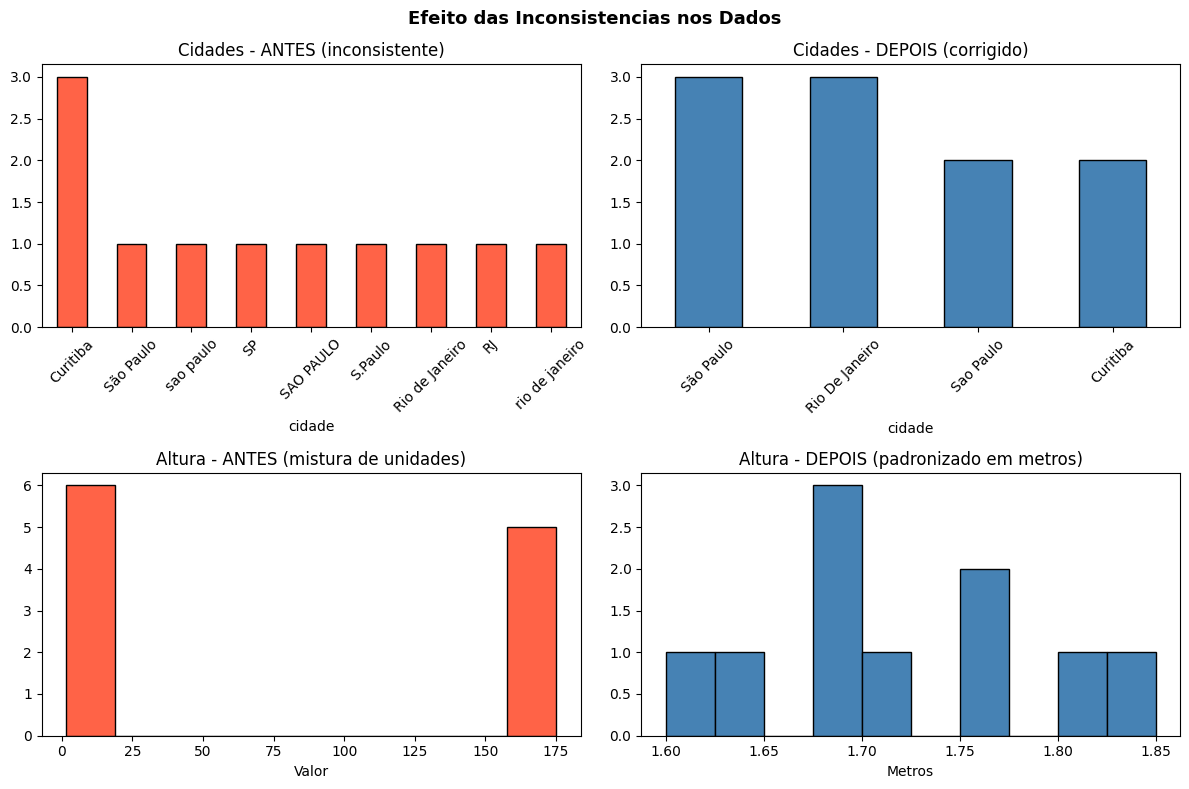

In [19]:
# Visualizacao: antes e depois
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

df_inc['cidade'].value_counts().plot(kind='bar', ax=axes[0, 0], color='tomato', edgecolor='black')
axes[0, 0].set_title('Cidades - ANTES (inconsistente)')
axes[0, 0].tick_params(axis='x', rotation=45)

df_limpo['cidade'].value_counts().plot(kind='bar', ax=axes[0, 1], color='steelblue', edgecolor='black')
axes[0, 1].set_title('Cidades - DEPOIS (corrigido)')
axes[0, 1].tick_params(axis='x', rotation=45)

axes[1, 0].hist(df_inc['altura'], bins=10, color='tomato', edgecolor='black')
axes[1, 0].set_title('Altura - ANTES (mistura de unidades)')
axes[1, 0].set_xlabel('Valor')

axes[1, 1].hist(df_limpo['altura'].dropna(), bins=10, color='steelblue', edgecolor='black')
axes[1, 1].set_title('Altura - DEPOIS (padronizado em metros)')
axes[1, 1].set_xlabel('Metros')

plt.suptitle('Efeito das Inconsistencias nos Dados', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [20]:
# Funcao de checklist de qualidade reutilizavel
def checklist_qualidade(df, nome='dataset'):
    print(f'=== CHECKLIST DE QUALIDADE: {nome.upper()} ===')
    print(f'Dimensoes: {df.shape[0]} linhas x {df.shape[1]} colunas')

    print('\n[1] Tipos de dados:')
    print(df.dtypes.to_string())

    print('\n[2] Completude:')
    pct = (df.isnull().sum() / len(df) * 100).round(1)
    for col, v in pct[pct > 0].items():
        alerta = ' <- ATENCAO' if v > 5 else ''
        print(f'  {col}: {v}%{alerta}')
    if pct.max() == 0:
        print('  Nenhum valor nulo.')

    print('\n[3] Unicidade:')
    print(f'  Linhas duplicadas exatas: {df.duplicated().sum()}')

    print('\n[4] Estatisticas (numericas):')
    display(df.describe().round(2))

    print('\n[5] Cardinalidade (categoricas):')
    for col in df.select_dtypes(include='object').columns:
        print(f'  {col}: {df[col].nunique()} valores unicos')

checklist_qualidade(df_limpo, 'apos correcao')

=== CHECKLIST DE QUALIDADE: APOS CORRECAO ===
Dimensoes: 10 linhas x 5 colunas

[1] Tipos de dados:
id          int64
cidade     object
altura    float64
genero     object
idade     float64

[2] Completude:
  idade: 20.0% <- ATENCAO

[3] Unicidade:
  Linhas duplicadas exatas: 0

[4] Estatisticas (numericas):


,id,altura,idade
count,10.00,10.00,8.00
mean,5.50,1.72,38.12
std,3.03,0.07,9.26
min,1.00,1.60,28.00
25%,3.25,1.68,32.00
50%,5.50,1.71,36.00
75%,7.75,1.76,42.50
max,10.00,1.85,55.00



[5] Cardinalidade (categoricas):
  cidade: 4 valores unicos
  genero: 2 valores unicos


<br>

---

## Resumo

<br>

**O que vimos neste notebook:**

- Qualidade de dados tem cinco dimensões: completude, consistência, acurácia, unicidade e atualidade
- O tipo da variável (contínua, discreta, nominal, ordinal, binária) define as técnicas adequadas de análise e codificação
- Granularidade incorreta é uma das principais causas de data leakage em modelos preditivos
- Parquet preserva tipos e é mais eficiente que CSV para datasets maiores
- CSVs brasileiros exigem atenção especial a separador, decimal e formato de data
- Inconsistências comuns precisam ser detectadas e corrigidas antes de qualquer modelagem

<br>

**Próximo notebook:** Limpeza e Preparação dos Dados.